## Voiced / Unvoiced Boundary Detection
Using low/high quefrency cepstrum regions + ZCR

**Cepstrum interpretation:**
- bins 1–10 (low quefrency): slow spectral envelope = vocal tract shape
- bins 20–100 (high quefrency): fast periodic ripple = pitch harmonics (voiced only)

### 1. Load + Pre-emphasis + Framing + Windowing

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

file = "data/heisenberg.mp3"

sig, sr = sf.read(file)

if len(sig.shape) > 1:
    sig = sig.mean(axis=1)

sig = sig.astype(np.float64)

print("SR:", sr, "  Length:", len(sig))

# same params as mfcc_manual
alpha    = 0.97
frame_ms = 25.0
step_ms  = 10.0

emph = np.append(sig[0], sig[1:] - alpha * sig[:-1])

frame_len = int(frame_ms * sr / 1000)
step_len  = int(step_ms  * sr / 1000)
num_frames = int((len(emph) - frame_len) / step_len) + 1

pad_len = num_frames * step_len + frame_len
padded  = np.zeros(pad_len)
padded[:len(emph)] = emph

frames = np.array([padded[i*step_len : i*step_len+frame_len] for i in range(num_frames)])
frames_w = frames * np.hamming(frame_len)

print("Frames:", frames.shape)

SR: 32000   Length: 493056
Frames: (1539, 800)


### 2. Real Cepstrum per Frame

In [2]:
NFFT = 512

def real_cepstrum(f, nfft=512):
    spec  = np.fft.rfft(f, n=nfft)
    log_s = np.log(np.abs(spec) + 1e-10)
    sym   = np.concatenate([log_s, log_s[-2:0:-1]])
    return np.real(np.fft.ifft(sym))

cepstrum = np.array([real_cepstrum(f, NFFT) for f in frames_w])
print("Cepstrum shape:", cepstrum.shape)

Cepstrum shape: (1539, 512)


### 3. Quefrency Features

In [3]:
low_e  = np.mean(np.abs(cepstrum[:,  1:11]),  axis=1)
high_e = np.max( np.abs(cepstrum[:, 20:101]), axis=1)

### 4. Zero Crossing Rate

In [4]:
def zcr(f):
    s = np.sign(f)
    s[s == 0] = 1
    return np.sum(np.abs(np.diff(s))) / (2.0 * len(f))

zcr_vals = np.array([zcr(f) for f in frames])

### 5. Classify Frames
A frame is voiced if high-q energy > adaptive threshold AND ZCR < 0.15

In [5]:
thresh_high = np.median(high_e) + 0.5 * np.std(high_e)
thresh_zcr  = 0.15

voiced = (high_e > thresh_high) & (zcr_vals < thresh_zcr)

print(f"Voiced frames  : {voiced.sum()}  ({100*voiced.mean():.1f}%)")
print(f"Unvoiced frames: {(~voiced).sum()}  ({100*(~voiced).mean():.1f}%)")
print(f"High-q threshold: {thresh_high:.5f}")

Voiced frames  : 43  (2.8%)
Unvoiced frames: 1496  (97.2%)
High-q threshold: 0.11006


### 6. Build Segments

In [6]:
times = np.arange(num_frames) * (step_ms/1000) + (frame_ms/1000)/2

segments  = []
cur_label = voiced[0]
seg_start = times[0]

for i in range(1, len(voiced)):
    if voiced[i] != cur_label:
        label = "voiced" if cur_label else "unvoiced"
        segments.append((seg_start, times[i], label))
        seg_start = times[i]
        cur_label = voiced[i]

label = "voiced" if cur_label else "unvoiced"
segments.append((seg_start, times[-1], label))

print(f"Total segments: {len(segments)}")
print(f"{'Start':>8}  {'End':>8}  {'Label':>10}  {'Dur ms':>8}")
print("-" * 42)
for s, e, lab in segments:
    print(f"{s:8.3f}  {e:8.3f}  {lab:>10}  {(e-s)*1000:8.1f}")

Total segments: 41
   Start       End       Label    Dur ms
------------------------------------------
   0.013     0.632    unvoiced     620.0
   0.632     0.652      voiced      20.0
   0.652     0.732    unvoiced      80.0
   0.732     0.742      voiced      10.0
   0.742     2.643    unvoiced    1900.0
   2.643     2.743      voiced     100.0
   2.743     2.753    unvoiced      10.0
   2.753     2.763      voiced      10.0
   2.763     2.833    unvoiced      70.0
   2.833     2.843      voiced      10.0
   2.843     2.863    unvoiced      20.0
   2.863     2.903      voiced      40.0
   2.903     2.913    unvoiced      10.0
   2.913     2.963      voiced      50.0
   2.963     3.233    unvoiced     270.0
   3.233     3.243      voiced      10.0
   3.243     3.263    unvoiced      20.0
   3.263     3.283      voiced      20.0
   3.283     3.293    unvoiced      10.0
   3.293     3.323      voiced      30.0
   3.323     3.333    unvoiced      10.0
   3.333     3.343      voiced      

### 7. Visualisation

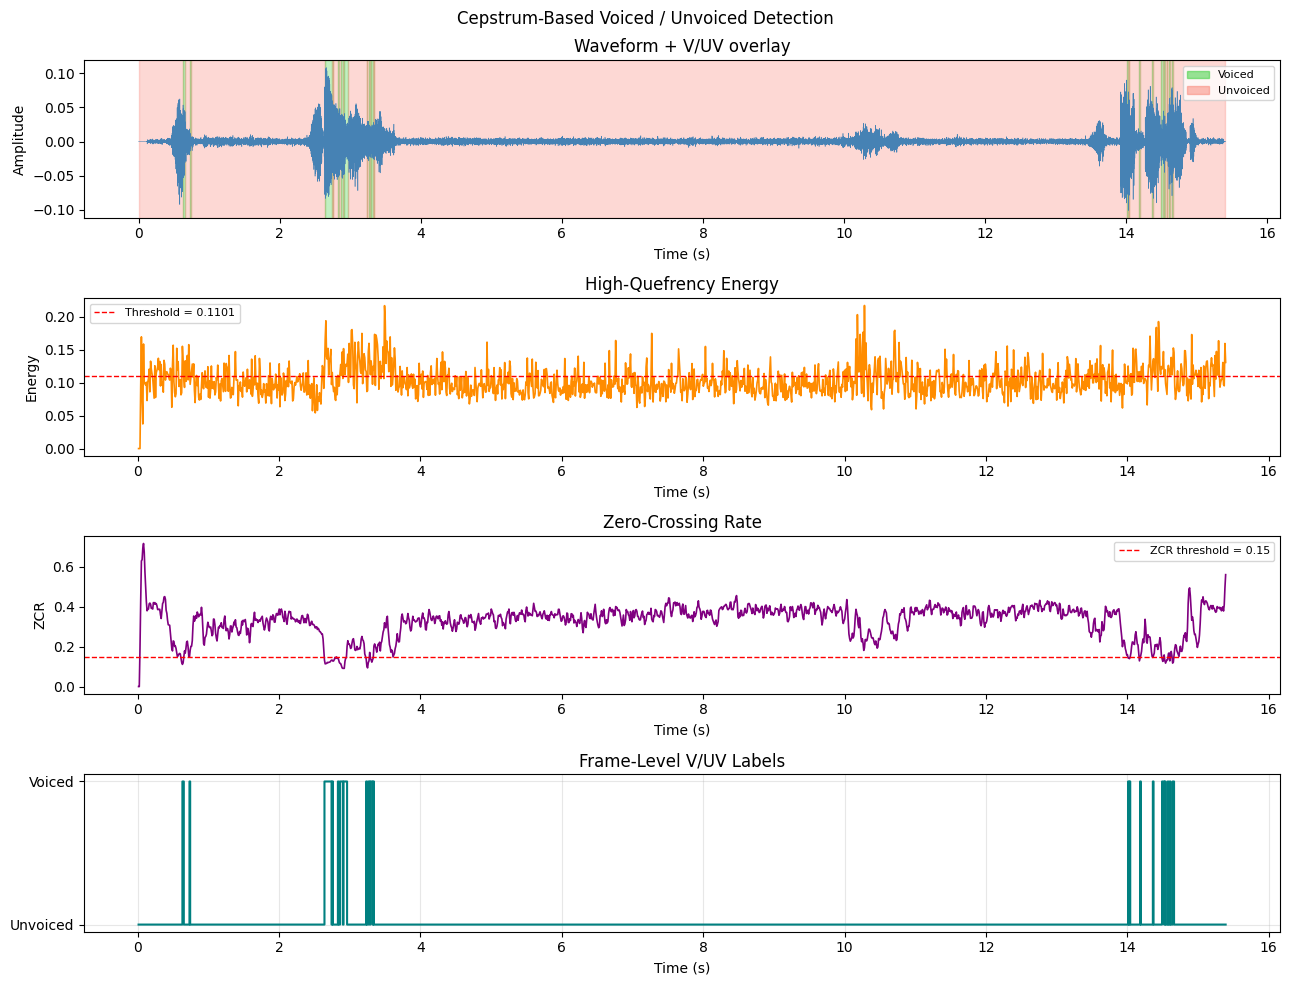

In [7]:
t_wav = np.arange(len(sig)) / sr

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=False)

axes[0].plot(t_wav, sig, lw=0.4, color="steelblue")
for s, e, lab in segments:
    c = "limegreen" if lab == "voiced" else "salmon"
    axes[0].axvspan(s, e, alpha=0.3, color=c)
axes[0].legend(handles=[
    mpatches.Patch(color="limegreen", alpha=0.5, label="Voiced"),
    mpatches.Patch(color="salmon",    alpha=0.5, label="Unvoiced")
], fontsize=8)
axes[0].set(title="Waveform + V/UV overlay", ylabel="Amplitude", xlabel="Time (s)")

axes[1].plot(times, high_e, color="darkorange", lw=1.2)
axes[1].axhline(thresh_high, color="red", ls="--", lw=1,
                label=f"Threshold = {thresh_high:.4f}")
axes[1].set(title="High-Quefrency Energy", ylabel="Energy", xlabel="Time (s)")
axes[1].legend(fontsize=8)

axes[2].plot(times, zcr_vals, color="purple", lw=1.2)
axes[2].axhline(thresh_zcr, color="red", ls="--", lw=1,
                label=f"ZCR threshold = {thresh_zcr}")
axes[2].set(title="Zero-Crossing Rate", ylabel="ZCR", xlabel="Time (s)")
axes[2].legend(fontsize=8)

axes[3].step(times, voiced.astype(int), where="post", color="teal", lw=1.5)
axes[3].set_yticks([0, 1])
axes[3].set_yticklabels(["Unvoiced", "Voiced"])
axes[3].set(title="Frame-Level V/UV Labels", xlabel="Time (s)")
axes[3].grid(alpha=0.3)

plt.suptitle("Cepstrum-Based Voiced / Unvoiced Detection", fontsize=12)
plt.tight_layout()
plt.savefig("voiced_unvoiced.png", dpi=150)
plt.show()